   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 652.1/652.1 kB 7.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.3 MB/s eta 0:00:0000:0100:01


[*********************100%%**********************]  1 of 1 completed


Durbin-Watson Test Statistic (after differencing): 2.9795376667342937


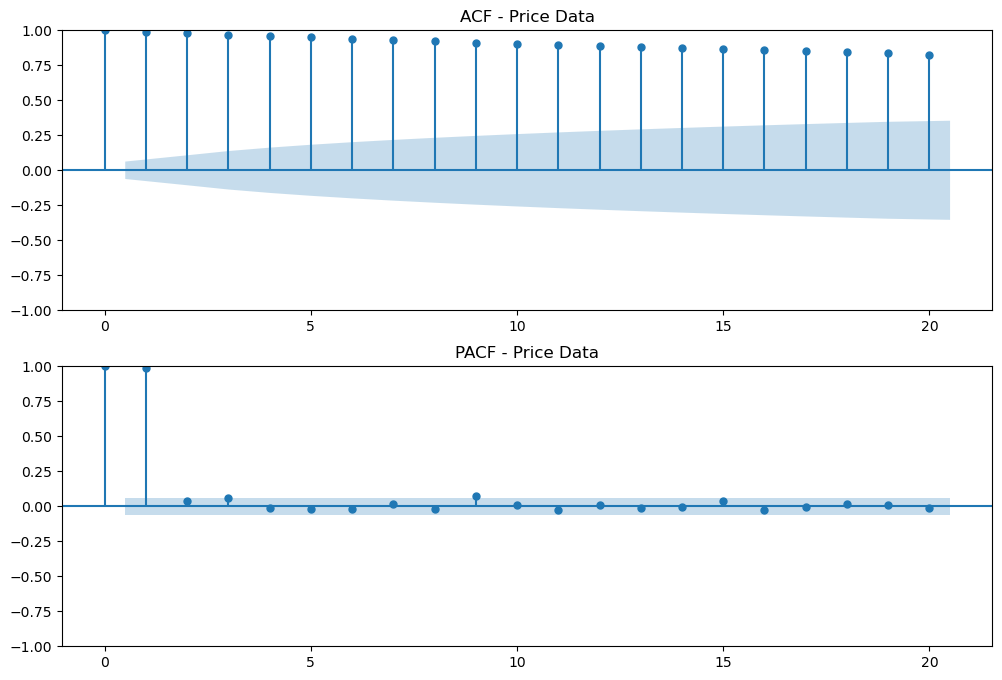

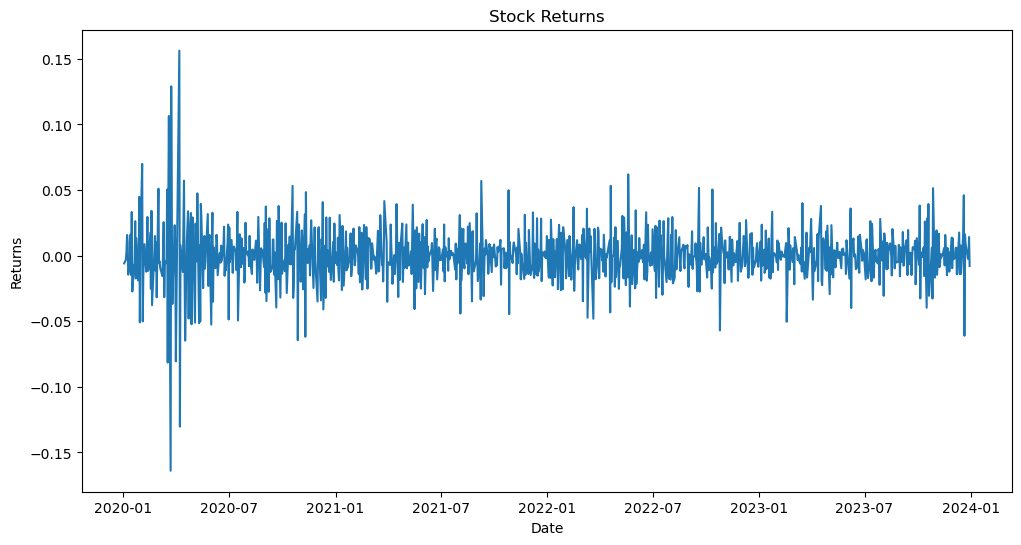

ADF Test Statistic: -12.022716472895807
p-value: 2.997563057637414e-22
KPSS Test Statistic: 0.14856171295223
p-value: 0.1
Performing stepwise search to minimize aic


/var/folders/wm/z8prq4x97w9bzh5q2bxqwzvc0000gp/T/ipykernel_10986/1416966531.py:65: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(data)  # Performing the KPSS test for stationarity.


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.89 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-4820.727, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-5090.187, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.31 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-5292.336, Time=0.11 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-5378.015, Time=0.14 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-5439.119, Time=0.20 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=-5445.573, Time=0.25 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=-5486.386, Time=0.73 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.65 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=-5560.599, Time=0.84 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.74 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=-5540.482, Time=0.96 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.87 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=-5513.066, Time=1.01 sec

Best model:  ARIMA(5,0,2

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                  990
Model:                 ARIMA(5, 0, 2)   Log Likelihood                2776.434
Date:                Sat, 11 May 2024   AIC                          -5534.867
Time:                        22:39:54   BIC                          -5490.788
Sample:                             0   HQIC                         -5518.106
                                - 990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.693e-06   3.28e-05     -0.052      0.959   -6.59e-05    6.25e-05
ar.L1         -0.6255      0.267     -2.346      0.019      -1.148      -0.103
ar.L2         -0.1848      0.041     -4.473      0.0

In [4]:
!pip install pmdarima

import yfinance as yf  # Importing the yfinance library, used to fetch historical market data from Yahoo Finance.
import pandas as pd  # Importing the pandas library, used for data manipulation and analysis.
import numpy as np  # Importing the numpy library, used for numerical computing.
import matplotlib.pyplot as plt  # Importing the matplotlib library, used for data visualization.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Importing plot_acf and plot_pacf functions
from statsmodels.tsa.stattools import adfuller, kpss  # Importing functions for stationarity tests.
from statsmodels.stats.stattools import durbin_watson  # Importing the Durbin-Watson test for autocorrelation.
from statsmodels.tsa.arima.model import ARIMA  # Importing the ARIMA model for time series analysis.
from pmdarima import auto_arima  # Importing the auto_arima function for automatic ARIMA model selection.
from datetime import datetime, timedelta  # Importing datetime-related modules for handling dates.
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Importing scalers for feature scaling in machine learning.

# Step 1: Extract historical price data from Yahoo Finance
def get_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)  # Fetching historical stock data.
    return stock_data['Adj Close']  # Returning adjusted close prices.

ticker = "NESTLEIND.NS"  # Stock ticker symbol.
start_date = "2020-01-01"  # Start date for data retrieval.
end_date = "2024-01-01"  # End date for data retrieval.
stock_prices = get_stock_data(ticker, start_date, end_date)  # Calling function to get stock data.

# Step 2: Compute the returns
# stock_returns = stock_prices.pct_change().dropna()
stock_returns = np.log(stock_prices / stock_prices.shift(1)).dropna()  # Calculating log returns.

# Step 3: Test for presence of autocorrelation
def test_autocorrelation(data):
    dw_test = durbin_watson(data)  # Performing the Durbin-Watson test for autocorrelation.
    return dw_test  # Returning the Durbin-Watson test statistic.

# Apply differencing to induce autocorrelation
differenced_data = stock_returns.diff().dropna()  # Differencing the data to induce autocorrelation.
dw_test_differenced = test_autocorrelation(differenced_data)  # Performing Durbin-Watson test on differenced data.
print("Durbin-Watson Test Statistic (after differencing):", dw_test_differenced)  # Printing test statistic.

# Step 4 (a): Generate ACF and PACF Plots on Price Data
def plot_acf_pacf_price(data):
    # ACF and PACF plots
    fig, ax = plt.subplots(2, figsize=(12, 8))  # Creating subplots for ACF and PACF.
    plot_acf(data, ax=ax[0], lags=20)  # Generating ACF plot for price data.
    plot_pacf(data, ax=ax[1], lags=20)  # Generating PACF plot for price data.
    ax[0].set_title('ACF - Price Data')  # Setting title for ACF plot.
    ax[1].set_title('PACF - Price Data')  # Setting title for PACF plot.
    plt.show()  # Displaying the plots.

# Generate ACF and PACF plots on the price data
plot_acf_pacf_price(stock_prices)  # Calling function to generate ACF and PACF plots.

# Step 4: Test for stationarity
def test_stationarity(data):
    plt.figure(figsize=(12, 6))  # Setting the figure size for the plot.
    plt.plot(data)  # Plotting the data.
    plt.title('Stock Returns')  # Setting title for the plot.
    plt.xlabel('Date')  # Setting label for the x-axis.
    plt.ylabel('Returns')  # Setting label for the y-axis.
    plt.show()  # Displaying the plot.
    
    adf_test = adfuller(data)  # Performing the Augmented Dickey-Fuller test for stationarity.
    print("ADF Test Statistic:", adf_test[0])  # Printing ADF test statistic.
    print("p-value:", adf_test[1])  # Printing p-value for ADF test.
    
    kpss_test = kpss(data)  # Performing the KPSS test for stationarity.
    print("KPSS Test Statistic:", kpss_test[0])  # Printing KPSS test statistic.
    print("p-value:", kpss_test[1])  # Printing p-value for KPSS test.
    
# Test for stationarity on the differenced data
test_stationarity(differenced_data)  # Calling function to test stationarity.

# Step 5: Determine the best ARIMA model order
auto_arima_model = auto_arima(differenced_data, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True, information_criterion='aic')  # Performing automatic ARIMA model selection.
print("Best ARIMA Model Order:", auto_arima_model.order)  # Printing the best ARIMA model order.

# Step 6: Estimate the parameters and print the ARIMA model summary
arima_model = ARIMA(differenced_data, order=auto_arima_model.order)  # Creating ARIMA model object.
arima_fit = arima_model.fit()  # Fitting the ARIMA model to the data.
print(arima_fit.summary())  # Printing the summary of the fitted ARIMA model.

# Step 7: Make predictions on the entire dataset using the model
predictions = arima_fit.predict()  # Generating predictions using the fitted ARIMA model.
print(predictions)  # Printing the predictions.
